In [ ]:
import torch
from torchmetrics.functional import pairwise_cosine_similarity

def hubness_direction(
    A: torch.Tensor,
    B: torch.Tensor,
) -> dict:
    """
    Directional hubness stats when mapping B -> nearest neighbor in A.

    a) top_hub_share: % of B items whose NN is the single most common A item
    b) anti_hub_share: % of A items that are NN for zero B items
    c) mean_fanout_given_used: among A items that are NN for >=1 B items,
       average count (# of B items assigned to them)

    Returns a dict with scalar floats.
    """
    # Distances [|B|, |A|], nearest A index for each B item
    dists = 1.0 - pairwise_cosine_similarity(B, A)
    nn_in_A = torch.argmin(dists, dim=1)  # smallest distance = nearest neighbor

    counts = torch.bincount(nn_in_A, minlength=A.size(0)).to(dists.dtype)  # [|A|] count of B items assigned to each A item
    Bn = float(B.size(0))
    An = float(A.size(0))

    top_count = float(counts.max().item()) if counts.numel() > 0 else 0.0 # count of most popular A item
    top_hub_share = top_count / Bn if Bn > 0 else 0.0 # fraction of B items assigned to it

    anti_hub_share = float((counts == 0).sum().item()) / An if An > 0 else 0.0 # fraction of A items never assigned

    used = counts[counts > 0] # counts of only those A items that were assigned >=1 B items
    mean_fanout = float(used.mean().item()) if used.numel() > 0 else 0.0 # average count among used A items

    return {
        "top_hub_share": top_hub_share,
        "anti_hub_share": anti_hub_share,
        "mean_fanout_given_used": mean_fanout,
        "A_size": int(A.size(0)),
        "B_size": int(B.size(0)),
    }


def hubness_bidir(
    t1: torch.Tensor,
    t2: torch.Tensor,
) -> dict:
    """
    Computes directional hubness both ways:
      - t2 -> t1  (how t1 acts as hubs for t2)
      - t1 -> t2  (how t2 acts as hubs for t1)

    Returns flattened dict with clear keys.
    """
    d21 = hubness_direction(A=t1, B=t2)  # B(t2) chooses NN in A(t1)
    d12 = hubness_direction(A=t2, B=t1)  # B(t1) chooses NN in A(t2)

    return {
        # t2 -> t1
        "hub_topshare_t2_to_t1": d21["top_hub_share"],
        "hub_antihubshare_t1_wrt_t2": d21["anti_hub_share"],
        "hub_meanfanout_t1_wrt_t2": d21["mean_fanout_given_used"],

        # t1 -> t2
        "hub_topshare_t1_to_t2": d12["top_hub_share"],
        "hub_antihubshare_t2_wrt_t1": d12["anti_hub_share"],
        "hub_meanfanout_t2_wrt_t1": d12["mean_fanout_given_used"],

        # sizes (optional but handy for debugging)
        "n_t1": d21["A_size"],
        "n_t2": d21["B_size"],
    }


In [ ]:
import torch
import pandas as pd
from def_proj_functions import load_semeval_df, \
        lang_specific_model_names, lang_specific_models, models, definition_models, languages

from metrics import calculate_apd, calculate_prt, calculate_amd, calculate_minimum_distance, calculate_greedy_symmetric_amd, calculate_optimal_symmetric_amd


def to_torch(x, ref):
    return torch.as_tensor(x, device=ref.device, dtype=ref.dtype)


def compute_metrics(embeddings, definition_embeddings, words, spaces, space_functions):
    words = [w.split('_')[0] for w in words]

    # base results frame
    results = pd.DataFrame({"words": words})

    # metric columns you compute
    metric_names = ["apd", "prt", "amd", "amd_sym", "amd_opt_sym"]

    # hubness columns (6 directional stats) + sizes (optional)
    hub_cols = [
        "hub_topshare_t2_to_t1",
        "hub_antihubshare_t1_wrt_t2",
        "hub_meanfanout_t1_wrt_t2",
        "hub_topshare_t1_to_t2",
        "hub_antihubshare_t2_wrt_t1",
        "hub_meanfanout_t2_wrt_t1",
        "n_t1",
        "n_t2",
    ]

    # initialize columns
    for space in spaces:
        for m in metric_names:
            results[f"{m}_{space}"] = None
        for h in hub_cols:
            results[f"{h}_{space}"] = None

    for i, word_usage_embeddings in enumerate(embeddings):
        word = words[i]
        word_definition_embeddings = definition_embeddings[word]
        num_defs = len(word_definition_embeddings)

        halfway = word_usage_embeddings.shape[0] // 2
        usage_embs_t1 = word_usage_embeddings[:halfway].squeeze()
        usage_embs_t2 = word_usage_embeddings[halfway:].squeeze()

        def_emb = torch.stack([to_torch(e, word_usage_embeddings) for e in word_definition_embeddings]).squeeze(1)

        ctx = {
            "word": word,
            "num_defs": num_defs,
            "word_usage_embeddings": word_usage_embeddings,
            "def_emb": def_emb,
        }

        for space, space_fn in zip(spaces, space_functions):
            t1_s, t2_s = space_fn(usage_embs_t1, usage_embs_t2, ctx)

            # --- your existing metrics ---
            apd = calculate_apd(t1_s, t2_s)
            prt = calculate_prt(t1_s, t2_s)
            amd = calculate_amd(t1_s, t2_s)
            amd_sym = calculate_greedy_symmetric_amd(t1_s, t2_s)
            amd_opt_sym = calculate_optimal_symmetric_amd(t1_s, t2_s)

            results.loc[i, f"apd_{space}"] = apd
            results.loc[i, f"prt_{space}"] = prt
            results.loc[i, f"amd_{space}"] = amd
            results.loc[i, f"amd_sym_{space}"] = amd_sym
            results.loc[i, f"amd_opt_sym_{space}"] = amd_opt_sym

            # --- hubness stats for this space ---
            h = hubness_bidir(t1_s, t2_s)
            for k, v in h.items():
                results.loc[i, f"{k}_{space}"] = v

    return results


In [6]:
import os, time, torch
from tqdm import tqdm
from spaces import return_full_space, def_space, pca_space, pca_space_num, random_dim_selection, random_dim_selection_num
from embed_defs_functions import compute_spearman_correlation
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

PATH_TO_DEF_EMBS = os.getenv('PATH_TO_DEF_EMBS')
PATH_TO_USAGE_EMBS = os.getenv('PATH_TO_USAGE_EMBS')


MASTER_CSV = './results/hubness.csv'

def ensure_csv_header(path=MASTER_CSV):
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        with open(path, 'w') as f:
            f.write("language,encoder,definition_gen_model,metric,space,spearman,timestamp,other\n")

def append_row_csv(language, encoder_name, def_model, metric, space, value, timestamp, other=""):
    ensure_csv_header()
    with open(MASTER_CSV, 'a') as f:
        f.write(f"{language},{encoder_name},{def_model},{metric},{space},{value},{timestamp},{other}\n")

HUB_METRICS = [
    "hub_topshare_t2_to_t1",
    "hub_antihubshare_t1_wrt_t2",
    "hub_meanfanout_t1_wrt_t2",
    "hub_topshare_t1_to_t2",
    "hub_antihubshare_t2_wrt_t1",
    "hub_meanfanout_t2_wrt_t1",
]

def append_hubness_rows(language, encoder_name, def_model, spaces, results, timestamp):
    for space in spaces:
        for hm in HUB_METRICS:
            col = f"{hm}_{space}"
            # ensure numeric
            vals = pd.to_numeric(results[col], errors="coerce")
            mean_val = float(vals.mean())
            append_row_csv(
                language=language,
                encoder_name=encoder_name,
                def_model=def_model,
                metric=hm,            # store hub metric name in "metric"
                space=space,
                value=mean_val,       # store mean hubness in "spearman" column (name is legacy)
                timestamp=timestamp,
                other="hubness_mean_over_words"
            )


def run_exp(spaces, space_functions):
    rows = []
    i = 0
    for language in languages:
        print(f"[[Processing language]]: {language}")
        df = load_semeval_df(language)
        # choose encoders the same way as before
        lang_encoders = models + lang_specific_models.get(language, [])

        for model in lang_encoders:
            # print(f"[Using encoder]: {model}")
            # tok, encoder = get_wordtransformer_model(model)

            # normalize encoder name consistently across both pipelines
            if '/' in model:
                encoder_name = lang_specific_model_names[model]
            else:
                encoder_name = model

            # load precomputed usage embeddings (your second loop did this)
            usage_path = f'{PATH_TO_USAGE_EMBS}/{language}_embeddings_by_{encoder_name}.pt'
            embeddings = torch.load(usage_path)

            for def_model in definition_models[:1]:  # == definition_gen_models in your second loop
                i += 1
                defs_dir = f'{PATH_TO_DEF_EMBS}/embeddings/{language}'
                os.makedirs(defs_dir, exist_ok=True)

                defs_path = f'{defs_dir}/{def_model}_definitions_embedded_by_{encoder_name}.pt'

                # 1) Load precomputed definition embeddings
                definition_embeddings = torch.load(defs_path)

                # 2) Compute metrics + scores (retain functionality of second loop)
                results = compute_metrics(embeddings, definition_embeddings, df['words'].tolist(), spaces=spaces, space_functions=space_functions)
                scores = compute_spearman_correlation(df, results, metric_cols=[f'{metric}_{space}' for space in spaces for metric in ['prt','apd','amd','amd_sym','amd_opt_sym']])


                timestamp = time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime())

                for (metric, space), value in scores.items():
                    row = {
                        "language": language,
                        "encoder": encoder_name,
                        "definition_gen_model": def_model,
                        "metric": metric,
                        "space": space,
                        "spearman": value,
                        "timestamp": timestamp,
                        "other": "",
                    }
                    rows.append(row)
                    append_row_csv(language, encoder_name, def_model, metric, space, value, timestamp, other="")

                append_hubness_rows(language, encoder_name, def_model, spaces, results, timestamp)


print("Running experiments...")
from functools import partial

run_exp(
    ['full','pca','def','rand'],
    [
        return_full_space,
        pca_space,
        def_space,
        random_dim_selection,
    ]
)



Running experiments...
[[Processing language]]: english


/Users/acw747/Projects/definition_projection/embed_defs_functions.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['words'] = df['words'].apply(lambda x: x.split('_')[0])
/Users/acw747/Projects/definition_projection/embed_defs_functions.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['words'] = df['words'].apply(lambda x: x.split('_')[0])
/Users/acw747/Projects/definition_projection/embed_defs_functions.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

[[Processing language]]: german
[[Processing language]]: swedish
[[Processing language]]: latin
[[Processing language]]: spanish
[[Processing language]]: chinese
[[Processing language]]: norwegian_1
[[Processing language]]: norwegian_2


In [7]:
HUB_METRICS = [
    "hub_topshare_t2_to_t1",
    "hub_antihubshare_t1_wrt_t2",
    "hub_meanfanout_t1_wrt_t2",
    "hub_topshare_t1_to_t2",
    "hub_antihubshare_t2_wrt_t1",
    "hub_meanfanout_t2_wrt_t1",
]

def hub_metric_meta(metric: str):
    """
    Returns (direction, kind) for plotting/ordering.
    direction: "t2→t1" or "t1→t2"
    kind: "topshare" | "antihubshare" | "meanfanout"
    """
    if "t2_to_t1" in metric or "t1_wrt_t2" in metric:
        direction = "t2→t1"  # B=t2 chooses NN in A=t1
    else:
        direction = "t1→t2"

    if "topshare" in metric:
        kind = "topshare"
    elif "antihubshare" in metric:
        kind = "antihubshare"
    elif "meanfanout" in metric:
        kind = "meanfanout"
    else:
        kind = "other"

    return direction, kind


In [9]:
import pandas as pd

def filter_hubness_rows(df: pd.DataFrame, hub_metrics=HUB_METRICS) -> pd.DataFrame:
    """
    Keep only hubness rows. Assumes hub metrics were stored with metric=<hub_metric>
    and the value is in df['spearman'] (legacy column name).
    """
    out = df[df["metric"].isin(hub_metrics)].copy()
    out["spearman"] = pd.to_numeric(out["spearman"], errors="coerce")
    out = out.dropna(subset=["spearman"])
    return out


def add_metric_space_col(df: pd.DataFrame) -> pd.DataFrame:
    """Adds metric_space = metric + '_' + space."""
    out = df.copy()
    out["metric_space"] = out["metric"].astype(str) + "_" + out["space"].astype(str)
    return out

def aggregate_hubness(df: pd.DataFrame, factor1: str, factor2: str) -> pd.DataFrame:
    """
    Mean/std/count of hubness (stored in df['spearman']) by factor1 × factor2.
    """
    return (
        df.groupby([factor1, factor2])["spearman"]
          .agg(["mean", "std", "count"])
          .reset_index()
          .sort_values([factor1, "mean"], ascending=[True, False])
    )


In [10]:
def hub_metric_order(metrics=None):
    if metrics is None:
        metrics = HUB_METRICS
    # direction order: t2→t1 then t1→t2
    dir_order = {"t2→t1": 0, "t1→t2": 1}
    kind_order = {"topshare": 0, "antihubshare": 1, "meanfanout": 2}

    def key(m):
        d, k = hub_metric_meta(m)
        return (dir_order.get(d, 99), kind_order.get(k, 99), m)

    return sorted(metrics, key=key)


def hub_metric_space_order(spaces, metrics=None):
    """
    Returns list like:
      hub_topshare_t2_to_t1_full, hub_antihubshare_t1_wrt_t2_full, ...
      hub_topshare_t2_to_t1_def, ...
    """
    if metrics is None:
        metrics = hub_metric_order()
    ordered = []
    for space in spaces:
        for m in metrics:
            ordered.append(f"{m}_{space}")
    return ordered

import matplotlib.pyplot as plt
import seaborn as sns

HUB_SHARE_METRICS = [
    "hub_topshare_t2_to_t1",
    "hub_antihubshare_t1_wrt_t2",
    "hub_topshare_t1_to_t2",
    "hub_antihubshare_t2_wrt_t1",
]
HUB_FANOUT_METRICS = [
    "hub_meanfanout_t1_wrt_t2",
    "hub_meanfanout_t2_wrt_t1",
]


def plot_hubness_heatmap(
    hub_effect_df: pd.DataFrame,
    *,
    row_col: str,
    col_col: str,
    title: str = "",
    annotate: bool = True,
    include_std: bool = True,
    fmt: str = ".3f",
    figsize: tuple | None = None,
    sort_rows: bool = False,
    sort_cols: bool = False,
    vmin=None,
    vmax=None,
    col_order: list | None = None,
    cmap: str = "viridis",
):
    """
    Generic heatmap for hubness effect tables (mean/std/count), similar to your plot_effect_heatmap.
    """
    df = hub_effect_df.copy()

    mean_mat = df.pivot_table(index=row_col, columns=col_col, values="mean")
    std_mat  = df.pivot_table(index=row_col, columns=col_col, values="std")
    std_mat  = std_mat.reindex(index=mean_mat.index, columns=mean_mat.columns)

    if sort_rows:
        order = mean_mat.mean(axis=1).sort_values(ascending=False).index
        mean_mat = mean_mat.loc[order]
        std_mat  = std_mat.loc[order]

    if sort_cols:
        order = mean_mat.mean(axis=0).sort_values(ascending=False).index
        mean_mat = mean_mat[order]
        std_mat  = std_mat[order]

    if col_order is not None:
        # keep only those present
        col_order = [c for c in col_order if c in mean_mat.columns]
        if col_order:
            mean_mat = mean_mat[col_order]
            std_mat  = std_mat[col_order]

    ann = None
    if annotate:
        ann = mean_mat.copy().astype(object)
        for r in mean_mat.index:
            for c in mean_mat.columns:
                m = mean_mat.loc[r, c]
                if pd.isna(m):
                    ann.loc[r, c] = ""
                elif include_std:
                    s = std_mat.loc[r, c]
                    ann.loc[r, c] = f"{format(m, fmt)}\n({format(s, fmt)})" if not pd.isna(s) else f"{format(m, fmt)}"
                else:
                    ann.loc[r, c] = format(m, fmt)

    if figsize is None:
        figsize = (max(6, 1 + 0.8 * mean_mat.shape[1]),
                   max(4, 1 + 0.6 * mean_mat.shape[0]))

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        mean_mat,
        ax=ax,
        cmap=cmap,
        annot=ann if annotate else False,
        fmt="",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": ""},
    )
    ax.set_title(title)
    ax.set_xlabel(col_col)
    ax.set_ylabel(row_col)
    ax.set_xticklabels([t.get_text().replace("_", " ") for t in ax.get_xticklabels()],
                       rotation=45, ha="right")
    ax.set_yticklabels([t.get_text().replace("_", " ").title() for t in ax.get_yticklabels()],
                       rotation=0)
    plt.tight_layout()
    plt.show()

    return mean_mat, std_mat


In [12]:
def plot_hubness_heatmap_hierarchical(
    effect_df: pd.DataFrame,
    *,
    row_col: str = "language",
    col_col: str = "metric_space",
    title: str = "",
    spaces: list[str] | None = None,
    annotate: bool = True,
    include_std: bool = True,
    fmt: str = ".3f",
    figsize: tuple | None = None,
    vmin=None,
    vmax=None,
    tick_fontsize: int = 11,
):
    """
    Hierarchical heatmap tailored to hubness, where columns are metric_space.

    Expected metric_space like: hub_topshare_t2_to_t1_full, ...
    Orders columns by space, then direction, then kind.
    """
    df = effect_df.copy()

    mean_mat = df.pivot_table(index=row_col, columns=col_col, values="mean")
    std_mat  = df.pivot_table(index=row_col, columns=col_col, values="std")
    std_mat  = std_mat.reindex(index=mean_mat.index, columns=mean_mat.columns)

    # column ordering
    if spaces is not None:
        ordered_cols = hub_metric_space_order(spaces, metrics=hub_metric_order())
        ordered_cols = [c for c in ordered_cols if c in mean_mat.columns]
        if ordered_cols:
            mean_mat = mean_mat[ordered_cols]
            std_mat  = std_mat[ordered_cols]

    # add average row (mean only)
    avg_row = mean_mat.mean(axis=0)
    avg_row.name = "Average"
    mean_mat = pd.concat([mean_mat, avg_row.to_frame().T])

    # annotations
    ann = None
    if annotate:
        ann = mean_mat.copy().astype(object)
        for r in mean_mat.index:
            for c in mean_mat.columns:
                m = mean_mat.loc[r, c]
                if pd.isna(m):
                    ann.loc[r, c] = ""
                elif include_std and r != "Average":
                    s = std_mat.loc[r, c] if (r in std_mat.index and c in std_mat.columns) else float("nan")
                    ann.loc[r, c] = f"{format(m, fmt)}\n({format(s, fmt)})" if not pd.isna(s) else f"{format(m, fmt)}"
                else:
                    ann.loc[r, c] = format(m, fmt)

    if figsize is None:
        figsize = (max(8, 1 + 0.55 * mean_mat.shape[1]),
                   max(5, 1 + 0.6 * mean_mat.shape[0]))

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        mean_mat,
        ax=ax,
        cmap="viridis",
        annot=ann if annotate else False,
        fmt="",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": ""},
    )

    # separators between spaces: 6 columns per space
    group_size = 6
    n_cols = mean_mat.shape[1]
    for x in range(group_size, n_cols, group_size):
        ax.axvline(x, color="black", linewidth=1, ymin=-0.1, ymax=1.0, clip_on=False)

    ax.set_title(title)
    ax.set_ylabel(row_col.capitalize(), fontsize=tick_fontsize + 1)
    ax.set_xlabel("")

    # Build hierarchical x labels:
    # bottom row: kind+direction per column
    # second row: space label per 6 columns
    cols = list(mean_mat.columns)

    def parse_metric_space(ms: str):
        # split at last '_' occurrence? not safe because metric contains underscores.
        # We know your format is metric + "_" + space, and space is last token after last underscore group.
        # So split from the right once:
        metric, space = ms.rsplit("_", 1)
        direction, kind = hub_metric_meta(metric)
        return metric, space, direction, kind

    # bottom labels: DIRECTION + KIND
    bottom_labels = []
    spaces_in_order = []
    for c in cols:
        if c == "Average":
            bottom_labels.append("AVG")
            spaces_in_order.append("")
        else:
            metric, sp, direction, kind = parse_metric_space(c)
            bottom_labels.append(f"{direction}\n{kind}")
            spaces_in_order.append(sp)

    ax.set_xticklabels(bottom_labels, rotation=0, ha="center", fontsize=tick_fontsize)
    ax.tick_params(axis="x", length=0, pad=2)

    # top (second line) labels: one per space group
    # compute group centers
    has_avg = (len(cols) > 0 and cols[-1] == "Average")
    n_metric_cols = len(cols) - (1 if has_avg else 0)
    n_groups = n_metric_cols // group_size

    group_centers = [g * group_size + (group_size - 1) / 2 + 0.5 for g in range(n_groups)]
    group_names = []
    for g in range(n_groups):
        # space from first col in group
        _, sp, _, _ = parse_metric_space(cols[g * group_size])
        group_names.append(sp.replace("_", " ").upper())

    if has_avg:
        group_centers.append(n_metric_cols + 0.5)
        group_names.append("")

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.xaxis.set_ticks_position("bottom")
    ax2.xaxis.set_label_position("bottom")
    ax2.set_xticks(group_centers)
    ax2.set_xticklabels(group_names, rotation=0, ha="center", fontsize=tick_fontsize + 1)
    ax2.tick_params(axis="x", length=0, pad=16)

    for side in ["top", "bottom", "left", "right"]:
        ax2.spines[side].set_visible(False)

    # y tick labels
    ax.set_yticklabels(
        [t.get_text().replace("_", " ").title() for t in ax.get_yticklabels()],
        rotation=0,
        fontsize=tick_fontsize,
    )

    plt.tight_layout()
    plt.show()

    # std avg row for convenience
    avg_std_row = std_mat.mean(axis=0)
    avg_std_row.name = "Average"
    std_mat = pd.concat([std_mat, avg_std_row.to_frame().T])

    return mean_mat, std_mat


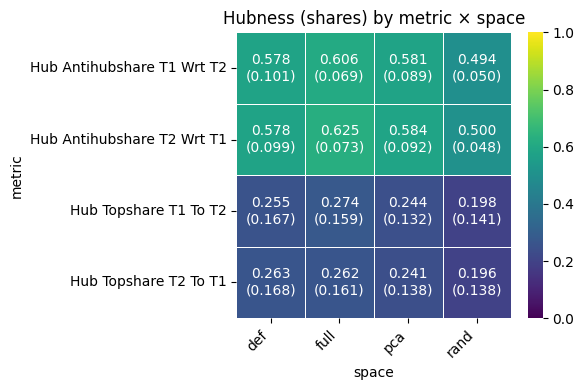

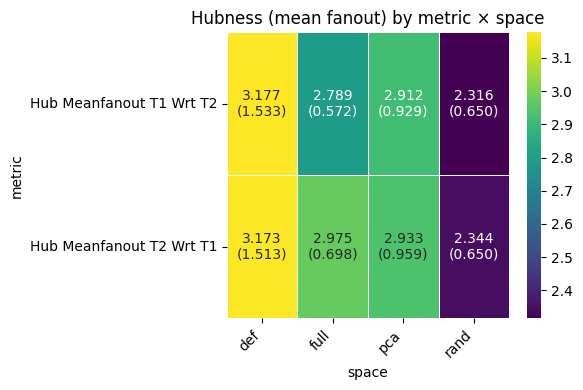

(space                          def      full       pca      rand
 metric                                                          
 hub_meanfanout_t1_wrt_t2  3.176928  2.788848  2.912394  2.316370
 hub_meanfanout_t2_wrt_t1  3.173252  2.975036  2.933376  2.343698,
 space                          def      full       pca      rand
 metric                                                          
 hub_meanfanout_t1_wrt_t2  1.532784  0.572022  0.929467  0.650393
 hub_meanfanout_t2_wrt_t1  1.513499  0.698051  0.958654  0.649647)

In [13]:
df = pd.read_csv('/Users/acw747/Projects/definition_projection/results/hubness.csv')

df_hub = filter_hubness_rows(df)

hub_effect = aggregate_hubness(df_hub, "metric", "space")

# Shares are 0..1, fanout is not; easiest: plot shares and fanout separately
hub_share = hub_effect[hub_effect["metric"].isin(HUB_SHARE_METRICS)]
plot_hubness_heatmap(
    hub_share,
    row_col="metric",
    col_col="space",
    title="Hubness (shares) by metric × space",
    vmin=0.0,
    vmax=1.0,
    sort_cols=False,
)

hub_fanout = hub_effect[hub_effect["metric"].isin(HUB_FANOUT_METRICS)]
plot_hubness_heatmap(
    hub_fanout,
    row_col="metric",
    col_col="space",
    title="Hubness (mean fanout) by metric × space",
    vmin=None,
    vmax=None,
    sort_cols=False,
)


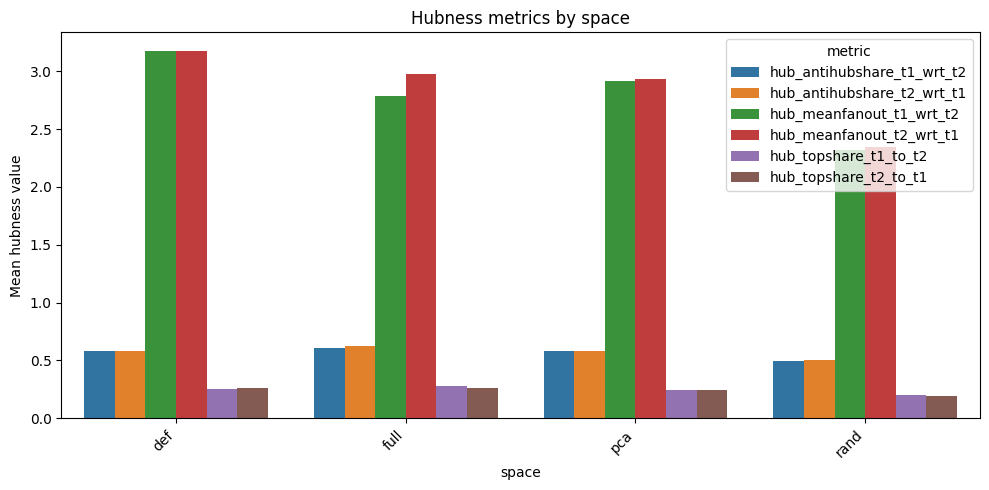

In [14]:
def plot_hubness_bars(df: pd.DataFrame, *, groupby=("space", "metric"), title="Hubness by space", figsize=(10,4)):
    """
    Barplot of mean hubness values with std error bars.
    """
    tmp = (
        df.groupby(list(groupby))["spearman"]
          .agg(["mean", "std", "count"])
          .reset_index()
    )
    tmp["se"] = tmp["std"] / (tmp["count"].clip(lower=1) ** 0.5)

    plt.figure(figsize=figsize)
    sns.barplot(data=tmp, x=groupby[0], y="mean", hue=groupby[1], errorbar=None)
    plt.title(title)
    plt.ylabel("Mean hubness value")
    plt.xlabel(groupby[0])
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_hubness_bars(
    df_hub,
    groupby=("space", "metric"),
    title="Hubness metrics by space",
    figsize=(10,5),
)